# **Project: Stock Price Prediction**

**Project Type:** Machine Learning

**Contribution:** Rohit Kumar Sain & Keshav Narayan Vyas  
**Program:** M.Sc. Computer Science (Semester IV)  
**Institution:** Maharaja Ganga Singh University (MGSU), Bikaner

##### **Project Summary:**

**Stock Price Prediction**

**Objective:**
Develop a machine learning model to predict the next day's stock closing price using historical stock market data.

**Data Collection:**
Historical daily stock data, including open, high, low, close prices, and trading volume, is collected using the Yahoo Finance API for a selected company.

**Methodology:**
The dataset is preprocessed and enhanced with features such as moving averages and trading volume indicators. These features are used to train a regression model, such as Linear Regression, Random Forest Regressor, etc. to learn stock price patterns and trends.

**Evaluation:**
The model's performance is assessed using Root Mean Square Error (RMSE) and Mean Absolute Error (MAE), which measure prediction accuracy by comparing predicted prices with actual closing prices.

**Outcome:**
The project demonstrates how machine learning techniques can be applied to financial data for short-term stock price forecasting, providing insights that may support investment decision-making.

### **Let's Begin**

#### Project Setup

Before starting, create a virtual environment to ensure the latest library versions run seamlessly:

1. Create the environment
`python -m venv venv`

2. Activate it on Windows (CMD):
`venv\Scripts\activate`

3. Install necessary libraries
`pip install yfinance pandas numpy scikit-learn matplotlib seaborn`

**1. Import Neccessary Libraries**

In [1]:
# Numerical Computation and Data Manipulation
import numpy as np
import pandas as pd
import math
# Yahoo Finance API
import yfinance as yf
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Feature Scaling and Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Filter Warning to ignore
import warnings
warnings.filterwarnings("ignore")

**2. Data Loading**

In [2]:
ticker = "SBIN.NS" #SBIN NSE stock tiker(symbol)
# Download dataset from Yahoo Finance API
data = yf.download(
    ticker,
    start="2006-01-01",
    end="2026-05-01"
)

[*********************100%***********************]  1 of 1 completed


**3. Data Inspection**

In [3]:
data.head() #Showing top 5 rows

Price,Close,High,Low,Open,Volume
Ticker,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS,SBIN.NS
Date,,,,,
2006-01-02,65.059860,65.983735,64.862143,65.606276,21240601
2006-01-03,65.573914,65.786008,65.138934,65.289921,17462401
2006-01-04,65.994522,66.361197,65.836344,65.836344,19420938
2006-01-05,67.676910,67.975286,66.087980,66.260535,42574671
2006-01-06,67.594231,68.302424,66.947157,67.655344,23846595


In [4]:
data.columns #showing columns name

MultiIndex([( 'Close', 'SBIN.NS'),
            (  'High', 'SBIN.NS'),
            (   'Low', 'SBIN.NS'),
            (  'Open', 'SBIN.NS'),
            ('Volume', 'SBIN.NS')],
           names=['Price', 'Ticker'])

In [5]:
# Fix multiIndex columns
data.columns = data.columns.get_level_values(0)

In [6]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [7]:
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2006-01-02,65.059860,65.983735,64.862143,65.606276,21240601
2006-01-03,65.573914,65.786008,65.138934,65.289921,17462401
2006-01-04,65.994522,66.361197,65.836344,65.836344,19420938
2006-01-05,67.676910,67.975286,66.087980,66.260535,42574671
2006-01-06,67.594231,68.302424,66.947157,67.655344,23846595


In [8]:
data.info() #infomation for dataframe 

<class 'pandas.DataFrame'>
DatetimeIndex: 5013 entries, 2006-01-02 to 2026-04-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5013 non-null   float64
 1   High    5013 non-null   float64
 2   Low     5013 non-null   float64
 3   Open    5013 non-null   float64
 4   Volume  5013 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.0 KB


In [9]:
data.describe() #statistical summary

Price,Close,High,Low,Open,Volume
count,5013.000000,5013.000000,5013.000000,5013.000000,5.013000e+03
mean,301.075132,304.958175,297.396433,301.394927,2.219863e+07
std,224.532089,226.283133,222.646615,224.576267,1.714428e+07
min,50.568264,52.263641,50.128855,51.263991,0.000000e+00
25%,163.863342,166.784703,161.008422,164.377557,1.238955e+07
50%,225.642349,228.835660,223.241159,226.085636,1.753465e+07
75%,343.109802,349.137227,332.686431,342.792567,2.573817e+07
max,1206.060669,1212.838437,1198.104026,1210.186291,2.626771e+08


In [10]:
# Missing values
data.isna().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [11]:
# Duplicate values
data.duplicated().sum()

np.int64(0)

**4. Data Preprocessing and Feature Engineering**

**The Simple Moving Average (SMA) Formula**

The Simple Moving Average is calculated by taking the arithmetic mean of a given set of prices over a specific number of periods. Mathematically, it is expressed as:

$$\text{SMA}_k = \frac{1}{k} \sum_{i=0}^{k-1} P_{t-i}$$

Where:
* $\text{SMA}_k$: The Simple Moving Average for a window size of $k$.
* $k$: The number of time periods (window size, e.g., 5 or 20 days).
* $P_{t-i}$: The closing price of the stock at a specific day in the past.

In [12]:
data["sma_5"] = data["Close"].rolling(5).mean()

data["sma_10"] = data["Close"].rolling(10).mean()

data["sma_20"] = data["Close"].rolling(20).mean()

**The 5-Day Volume Moving Average ($\text{VMA}_5$) Formula**

The 5-day Volume Moving Average calculates the average number of shares traded over the last 5 consecutive trading sessions to smooth out daily volume spikes. The mathematical formula is expressed as:

$$\text{VMA}_5 = \frac{1}{5} \sum_{i=0}^{4} V_{t-i}$$

Where:
* $\text{VMA}_5$: The Volume Moving Average for a 5-day window.
* $V_{t-i}$: The trading volume (number of shares traded) on day $t-i$.

In [13]:
data["Vol_MA_5"] = data["Volume"].rolling(5).mean()

**The Daily Return Percentage Formula**

The daily return measures the percentage gain or loss of a stock's price from the previous trading day. The mathematical formula is expressed as:

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

Where:
* $R_t$: The daily return on day $t$.
* $P_t$: The closing price on day $t$ (today).
* $P_{t-1}$: The closing price on day $t-1$ (yesterday).

In Pandas, we can use the `.pct_change()` method to calculate the percentage change between consecutive rows. The mathematical formula is expressed as follows:
$$\text{Percentage Change} = \frac{\text{Current Value} - \text{Previous Value}}{\text{Previous Value}}$$

In [14]:
data["return_1"] = data["Close"].pct_change()

data["return_3"] = data["Close"].pct_change(3)

**The Exponential Moving Average (EMA) Formula**

The Exponential Moving Average is calculated by applying more weight to the most recent prices, making it more responsive to new information. Mathematically, it is expressed as:

$$\text{EMA}_t = \left[ P_t \times \left( \frac{2}{k + 1} \right) \right] + \left[ \text{EMA}_{t-1} \times \left( 1 - \frac{2}{k + 1} \right) \right]$$

Where:
* $\text{EMA}_t$: The Exponential Moving Average for the current period.
* $P_t$: The closing price of the stock for the current period.
* $\text{EMA}_{t-1}$: The Exponential Moving Average value of the previous period.
* $k$: The number of time periods (window size, e.g., 10 or 50 days).


In [15]:
data["ema_10"] = data["Close"].ewm(span=10, adjust=False).mean()

**The Rolling Volatility (Historical Standard Deviation) Formula**

The Rolling Volatility is calculated by finding the standard deviation of asset returns over a moving window of a specific number of periods. Mathematically, it is expressed as:

$$\sigma_k = \sqrt{\frac{1}{k - 1} \sum_{i=0}^{k-1} (R_{t-i} - \bar{R})^2}$$

Where:
* $\sigma_k$: The rolling volatility (sample standard deviation) for a window size of $k$.
* $k$: The number of time periods (window size, e.g., 10 days).
* $R_{t-i}$: The return of the stock at a specific day within the window.
* $\bar{R}$: The arithmetic mean of the returns over the $k$ periods.


In [16]:
data["volatility_10"] = data["return_1"].rolling(10).std()

**The Percentage Change Formula**

The percentage change calculates the relative difference between the current value and the previous value in a sequence. Mathematically, it is expressed as:

$$PC_t = \frac{V_t - V_{t-1}}{V_{t-1}}$$

Where:
* $PC_t$: The percentage change at the current time period $t$.
* $V_t$: The value at the current time period $t$ (e.g., `data["Volume"]` for the current row).
* $V_{t-1}$: The value at the immediately preceding time period $t-1$ (e.g., `data["Volume"]` for the previous row).


In [17]:
data["volume_change"] = data["Volume"].pct_change()

**The 5-Period Momentum Formula**

The 5-period momentum calculates the percentage change in the closing price over a moving window of 5 time intervals. Mathematically, it is expressed as:

$$M_{t,5} = \frac{C_t}{C_{t-5}} - 1$$

Where:
* $M_{t,5}$: The 5-period momentum value at the current time period $t$.
* $C_t$: The closing price at the current time period $t$ (`data["Close"]`).
* $C_{t-5}$: The closing price exactly 5 time periods prior to the current row (`data["Close"].shift(5)`).


In [18]:
data['momentum_5'] = (data['Close'] / data['Close'].shift(5)) - 1

**The 1-Period Lag (Delayed Return) Formula**

The 1-period lag shifts a time-series dataset backward by one interval to align past values with current dates. Mathematically, it is expressed as:

$$L_{t,1} = R_{t-1}$$

Where:
* $L_{t,1}$: The lagged return value at the current time period $t$ (`data["return_lag1"]`).
* $R_{t-1}$: The return value from exactly one time period prior to the current row (`data["return_1"].shift(1)`).


In [19]:
data["return_lag1"] = data["return_1"].shift(1)

In [20]:
data.head(30) #show new features added

Price,Close,High,Low,Open,Volume,sma_5,sma_10,sma_20,Vol_MA_5,return_1,return_3,ema_10,volatility_10,volume_change,momentum_5,return_lag1
Date,,,,,,,,,,,,,,,,
2006-01-02,65.059860,65.983735,64.862143,65.606276,21240601,NaN,NaN,NaN,NaN,NaN,NaN,65.059860,NaN,NaN,NaN,NaN
2006-01-03,65.573914,65.786008,65.138934,65.289921,17462401,NaN,NaN,NaN,NaN,0.007901,NaN,65.153324,NaN,-0.177876,NaN,NaN
2006-01-04,65.994522,66.361197,65.836344,65.836344,19420938,NaN,NaN,NaN,NaN,0.006414,NaN,65.306269,NaN,0.112157,NaN,0.007901
2006-01-05,67.676910,67.975286,66.087980,66.260535,42574671,NaN,NaN,NaN,NaN,0.025493,0.040225,65.737295,NaN,1.192205,NaN,0.006414
2006-01-06,67.594231,68.302424,66.947157,67.655344,23846595,66.379887,NaN,NaN,24909041.2,-0.001222,0.030810,66.074920,NaN,-0.439888,NaN,0.025493
2006-01-09,66.645187,68.137059,66.289297,68.137059,22970843,66.696953,NaN,NaN,25255089.6,-0.014040,0.009859,66.178605,NaN,-0.036724,0.024367,-0.001222
2006-01-10,65.505608,67.137676,65.293513,66.433087,27809666,66.683292,NaN,NaN,27324542.6,-0.017099,-0.032083,66.056242,NaN,0.210651,-0.001042,-0.014040
2006-01-12,67.076561,67.288656,64.995131,65.498415,33539820,66.899699,NaN,NaN,30148319.0,0.023982,-0.007658,66.241754,NaN,0.206049,0.016396,-0.017099
2006-01-13,66.418694,67.432448,66.220976,67.223946,21138282,66.648056,NaN,NaN,25861041.2,-0.009808,-0.003399,66.273925,NaN,-0.369756,-0.018592,0.023982


**Target Variable to predict next day closing price**

In [21]:
data["Target"] = data["Close"].shift(-1) #Define target variable

data.replace([np.inf, -np.inf], np.nan, inplace=True) #Replace all infinite values to NaN

data.dropna(inplace=True) #Remove all missing values

**5. Exploratory Data Analysis (EDA)**

**Line Chart for Close Price, Returns, Moving Averages, Volatility, Volume Change**

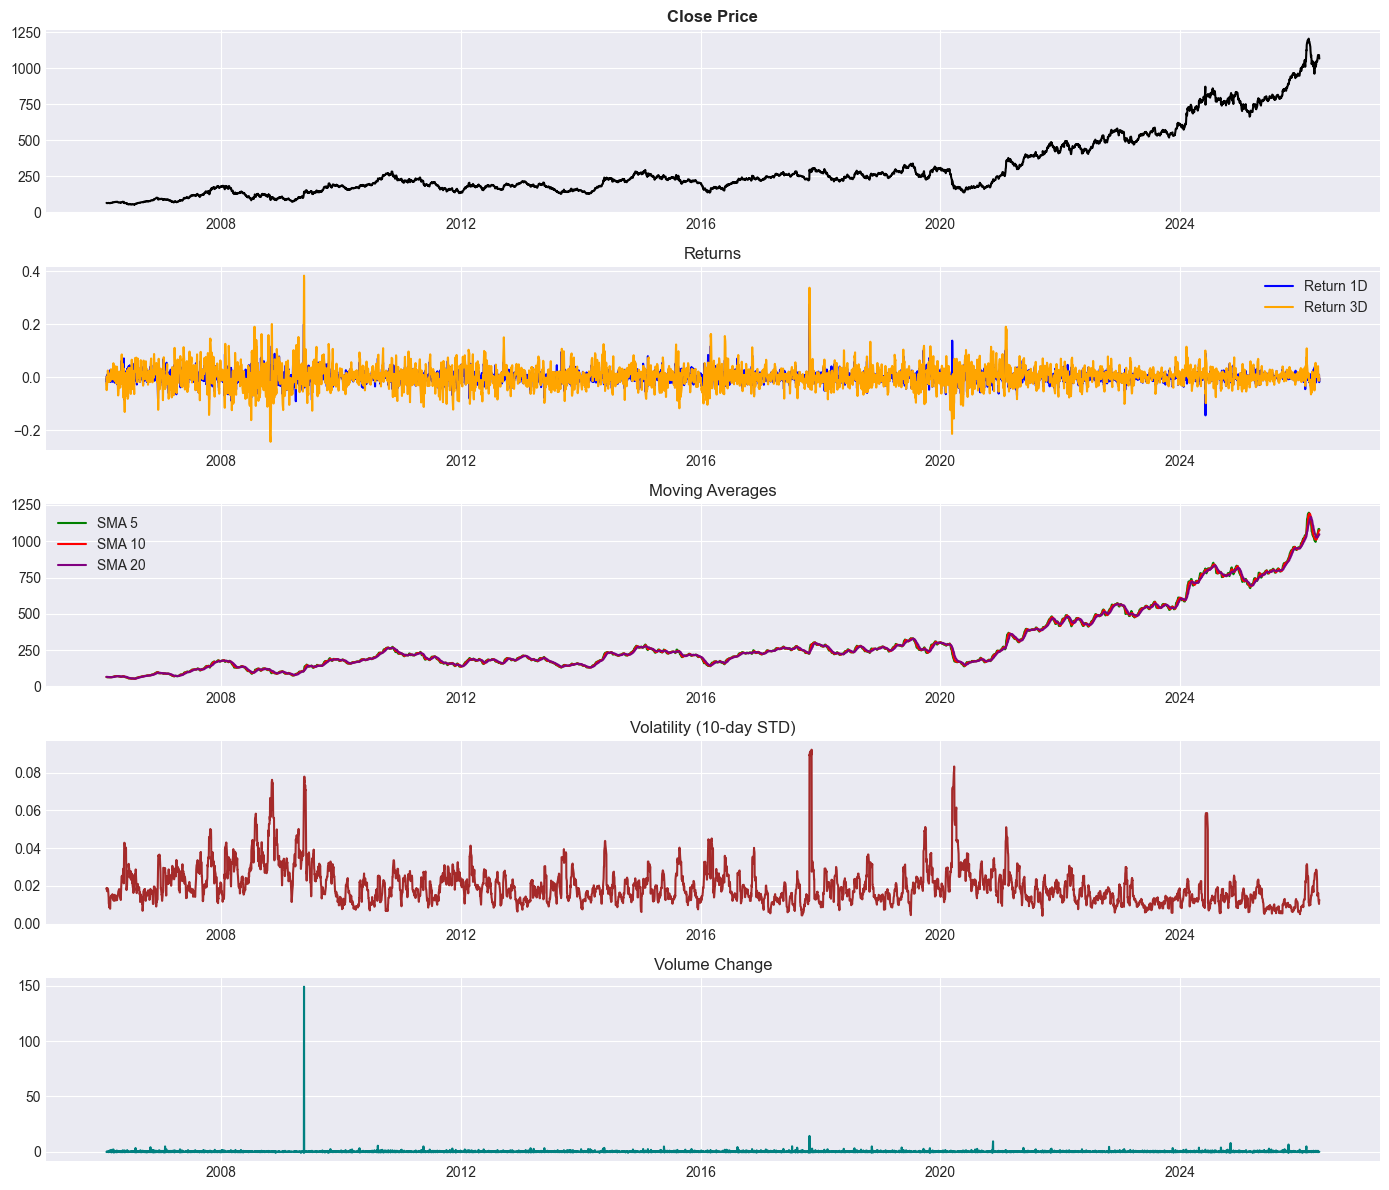

In [22]:
# Set the style and figure size
plt.style.use("seaborn-v0_8-darkgrid")

fig, axes = plt.subplots(5, 1, figsize=(14, 12))

# Price
axes[0].plot(data.index, data["Close"], color="black")
axes[0].set_title("Close Price", fontsize=12, fontweight="bold")

# Returns
axes[1].plot(data.index, data["return_1"], label="Return 1D", color="blue")
axes[1].plot(data.index, data["return_3"], label="Return 3D", color="orange")
axes[1].set_title("Returns")
axes[1].legend()

# Moving Averages
axes[2].plot(data.index, data["sma_5"], label="SMA 5", color="green")
axes[2].plot(data.index, data["sma_10"], label="SMA 10", color="red")
axes[2].plot(data.index, data["sma_20"], label="SMA 20", color="purple")
axes[2].set_title("Moving Averages")
axes[2].legend()

# Volatility
axes[3].plot(data.index, data["volatility_10"], color="brown")
axes[3].set_title("Volatility (10-day STD)")

# Volume Change
axes[4].plot(data.index, data["volume_change"], color="teal")
axes[4].set_title("Volume Change")

plt.tight_layout()
plt.show()

**Heatmap for Feature Correlation**

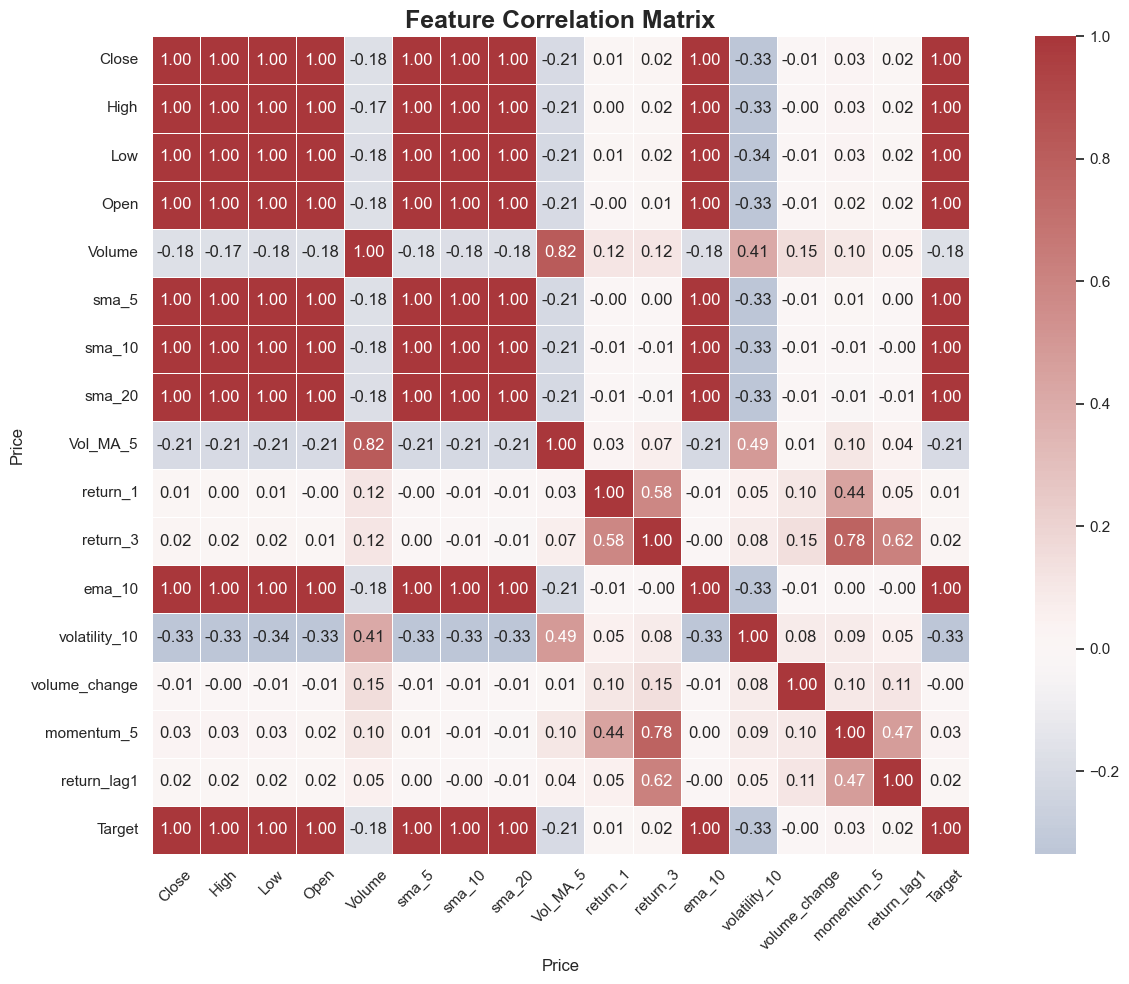

In [23]:
# Set the style and figure size
sns.set_theme(style="white")
plt.figure(figsize=(14, 10))

# Compute the correlation matrix
corr = data.corr()

# Draw the improved heatmap
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt=".2f", square=True, linewidths=0.5)

# Polish the labels and titles
plt.title("Feature Correlation Matrix", fontsize=18, fontweight="bold")
plt.xticks(rotation=45, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

plt.show()


**6. Machine Learning**

In [24]:
data.head(2)

Price,Close,High,Low,Open,Volume,sma_5,sma_10,sma_20,Vol_MA_5,return_1,return_3,ema_10,volatility_10,volume_change,momentum_5,return_lag1,Target
Date,,,,,,,,,,,,,,,,,
2006-01-31,63.726151,64.348063,63.172543,63.988574,25412634,64.290543,64.628819,65.489612,29340432.6,0.002942,0.001299,64.646549,0.018374,-0.255344,-0.017949,-0.032832,62.496723
2006-02-01,62.496723,64.096439,62.263054,63.916697,23565541,63.820341,64.351297,65.361456,29206849.8,-0.019292,-0.048700,64.255671,0.018962,-0.072684,-0.036254,0.002942,62.191151


**Feature Selection and Target Separation**

In [25]:
feature_cols = [
    "return_1",
    "return_3",
    "sma_5",
    "sma_10",
    "sma_20",
    "ema_10",
    "Vol_MA_5",
    "volatility_10",
    "volume_change",
    "momentum_5",
    "return_lag1"
]

# Combine features and target to drop NaNs across rows cleanly
all_cols = feature_cols + ["Target"]
clean_data = data[all_cols].dropna() # Drops the first  20 empty window rows

X = clean_data[feature_cols] # Indepencent features
y = clean_data["Target"] #Dependent variable

**Splitting data into Train and test dataset**

In [26]:
split = int(len(data) * 0.8) #split into 80% data for taining

# Features spliting
X_train = X.iloc[:split] 
X_test = X.iloc[split:]

# Target spliting
y_train = y.iloc[:split]
y_test = y.iloc[split:]

**ML Algorithms**

In [27]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

**Model Training**

In [28]:
baseline_train_results = [] #taining result stores here
baseline_test_results = [] #testing result stores here

for name, model in models.items():

    # Create pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    # train the pipeline
    pipe.fit(X_train, y_train)

    # predict over training dataset
    train_pred = pipe.predict(X_train)
    # predict over testing dataset
    test_pred = pipe.predict(X_test)

    # evaluation metrics for training
    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2 = r2_score(y_train, train_pred)

    # evaluation metrics for testing
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    # append metrices into train result list
    baseline_train_results.append([
        name,
        train_mae,
        train_rmse,
        train_r2
    ])
    # append metrices into test result list
    baseline_test_results.append([
        name,
        test_mae,
        test_rmse,
        test_r2
    ])

**Evaluation of Training dataset**

In [29]:
# convert into dataframe with columns names
baseline_train_df = pd.DataFrame(
    baseline_train_results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

print("Train Dataset")

baseline_train_df.sort_values(
    ["R2",
    "MAE",
    "RMSE"],
    ascending=False,
    ignore_index=True
)


Train Dataset


,Model,MAE,RMSE,R2
0,DecisionTree,0.000000,0.000000,1.000000
1,RandomForest,1.365659,1.983009,0.999448
2,GradientBoosting,3.033056,4.123997,0.997613
3,LinearRegression,3.490379,4.979815,0.996519
4,Ridge,3.634768,5.161586,0.996260
5,Lasso,3.829110,5.471395,0.995798


**Evaluation of Testing dataset**

In [30]:
# convert into dataframe with columns names
baseline_test_df = pd.DataFrame(
    baseline_test_results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

print("Test Dataset")

baseline_test_df.sort_values(
    ["R2",
    "MAE",
    "RMSE"],
    ascending=False,
    ignore_index=True
)

Test Dataset


,Model,MAE,RMSE,R2
0,LinearRegression,8.360233,11.940626,0.995559
1,Ridge,9.591169,13.619157,0.994222
2,Lasso,11.773035,15.859816,0.992165
3,DecisionTree,224.916228,285.196715,-1.533604
4,RandomForest,224.987581,285.351223,-1.536350
5,GradientBoosting,225.058033,285.501411,-1.539021


**Data Visualization of Models Performance**

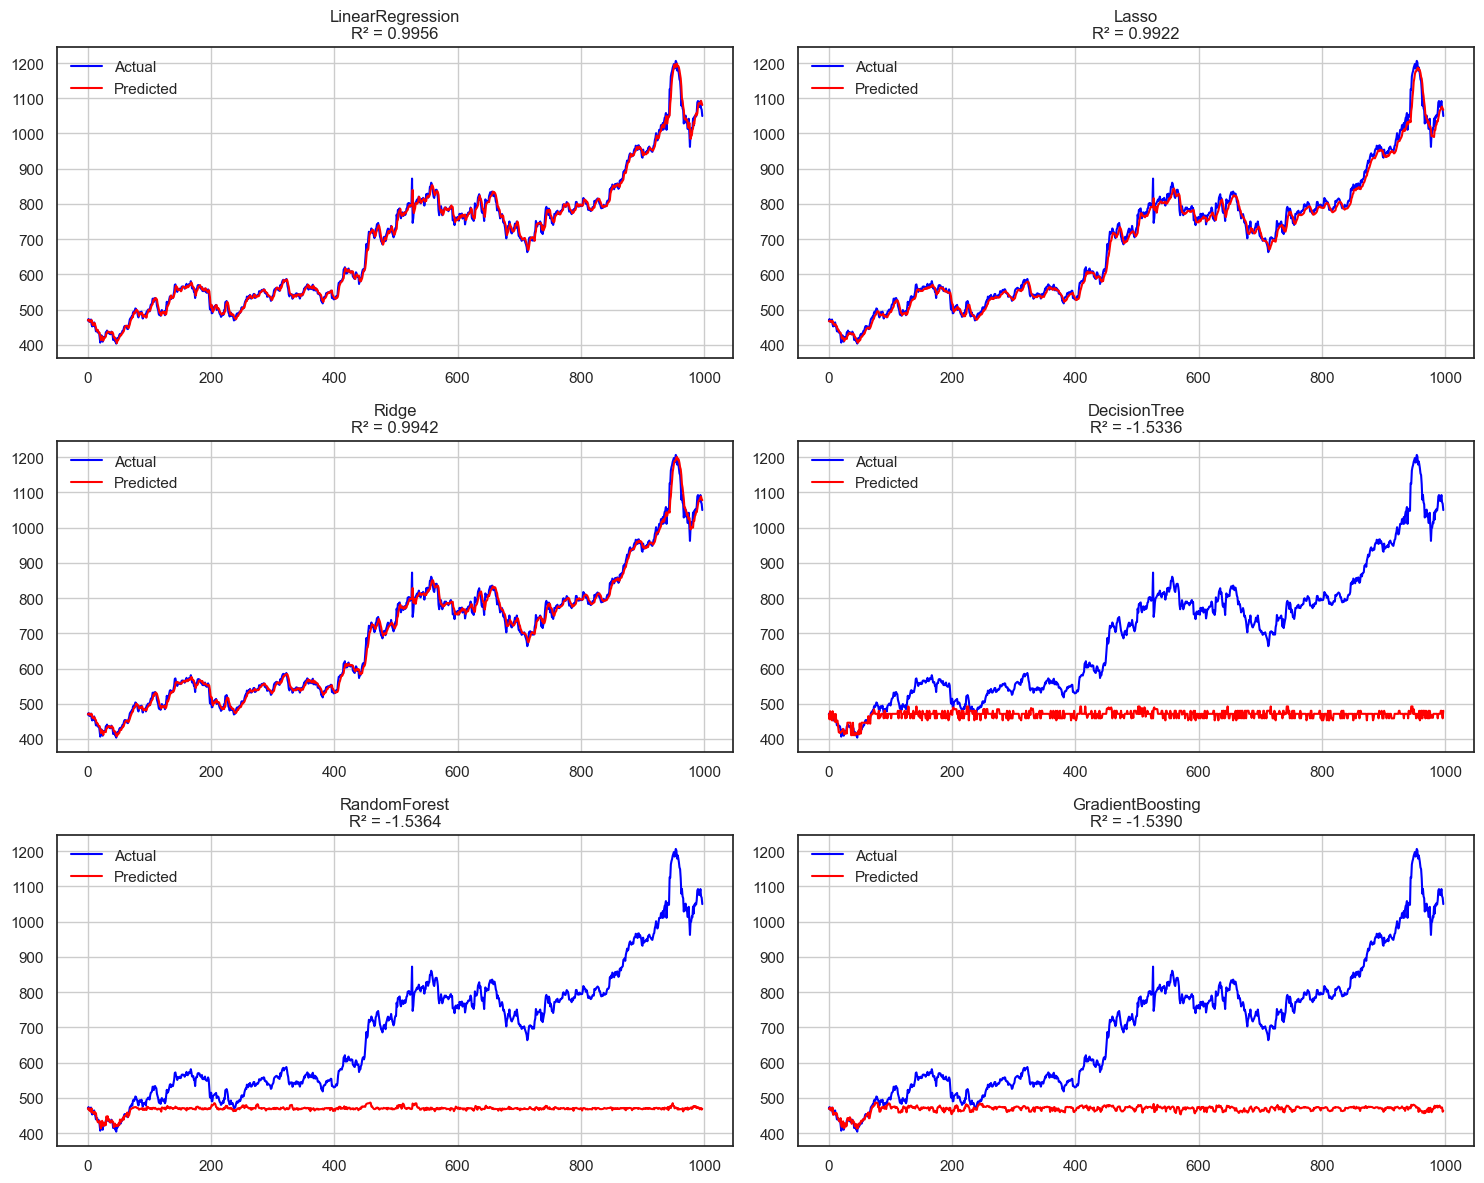

In [31]:
n_models = len(models) #number of models
n_cols = 2 #number of columns
n_rows = math.ceil(n_models / n_cols) #number of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):

    # create pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    # train the pipeline 
    pipe.fit(X_train, y_train)
    # prediction
    y_pred = pipe.predict(X_test)

    ax.plot(y_test.values, label="Actual", color="blue") #plot real stock values
    ax.plot(y_pred, label="Predicted", color="red") #plot predicted stock values

    r2 = r2_score(y_test, y_pred)

    ax.set_title(f"{name}\nR² = {r2:.4f}")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

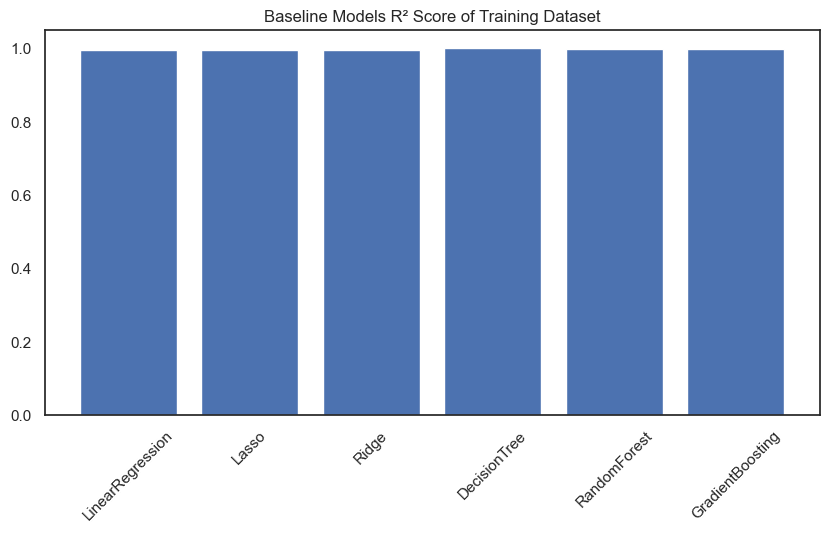

In [32]:
plt.figure(figsize=(10,5))

plt.bar(
    baseline_train_df["Model"],
    baseline_train_df["R2"]
)

plt.xticks(rotation=45)

plt.title("Baseline Models R² Score of Training Dataset")

plt.show()

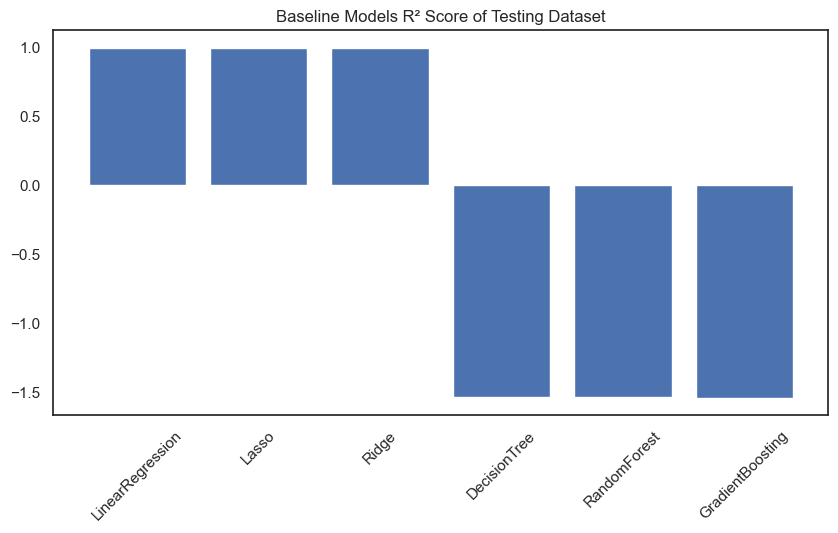

In [33]:
plt.figure(figsize=(10,5))

plt.bar(
    baseline_test_df["Model"],
    baseline_test_df["R2"]
)

plt.xticks(rotation=45)

plt.title("Baseline Models R² Score of Testing Dataset")

plt.show()

Based on the train and test evaluations, Linear Regression Ridge, and Lasso is the best model here according to the MAE, RMSE, and $R^2$ scores.

**Hyperparamter Tuning and Optimization**

In [34]:
# 1. Define pipelines that include scaling
pipe_linear = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
pipe_ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
pipe_lasso = Pipeline([('scaler', StandardScaler()), ('model', Lasso())])

In [35]:
# 2. Update parameter grids to target the model step inside the pipeline
param_grid_linear = {
    'model__fit_intercept': [True, False],
    'model__positive': [True, False]
}

param_grid_ridge = {
    'model__alpha': np.logspace(-4, 4, 20),
    'model__fit_intercept': [True, False],
    'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg']
}

param_grid_lasso = {
    'model__alpha': np.logspace(-4, 4, 20),
    'model__fit_intercept': [True, False],
    'model__max_iter': [1000, 5000, 10000]
}

In [36]:
# 3. Run Grid Search on the pipelines
grid_search_linear = GridSearchCV(pipe_linear, param_grid=param_grid_linear, cv=5, scoring='neg_mean_absolute_error').fit(X_train, y_train)
grid_search_ridge = GridSearchCV(pipe_ridge, param_grid=param_grid_ridge, cv=5, scoring='neg_mean_absolute_error').fit(X_train, y_train)
grid_search_lasso = GridSearchCV(pipe_lasso, param_grid=param_grid_lasso, cv=5, scoring='neg_mean_absolute_error').fit(X_train, y_train)

In [37]:
# store all grid search models in a dictionary
models_dict = {
    'Linear Regression': grid_search_linear,
    'Ridge Regression': grid_search_ridge,
    'Lasso Regression': grid_search_lasso
}

# create an empty list to store results
results_list = []

# loop through each model
for name, model in models_dict.items():

    # Remove the pipeline prefix from parameter names
    clean_params = {}
    for key, value in model.best_params_.items():
        clean_params[key.split('__')[1]] = value

    # Save results
    results_list.append({
        'Model': name,
        'Best MAE': -model.best_score_,  # Convert negative MAE to positive MAE
        'Best Parameters': clean_params
    })

# convert results to a DataFrame
results_df = pd.DataFrame(results_list)

# display results
results_df

,Model,Best MAE,Best Parameters
0,Linear Regression,3.628157,"{'fit_intercept': True, 'positive': False}"
1,Ridge Regression,3.628219,"{'alpha': 0.0001, 'fit_intercept': True, 'solv..."
2,Lasso Regression,3.758236,"{'alpha': 0.0001, 'fit_intercept': True, 'max_..."


In [38]:
# create the final pipeline with specific parameters
final_model_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression(fit_intercept=True, positive=False))
])

# fit the model on the full training dataset
final_model_pipe.fit(X_train, y_train)

# generate final predictions on the test dataset
y_pred_final = final_model_pipe.predict(X_test)

# calculate performance metrics
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print(f"Final Model Test RMSE: {final_rmse:.4f}")
print(f"Final Model Test R²: {final_r2:.4f}")


Final Model Test RMSE: 11.9406
Final Model Test R²: 0.9956


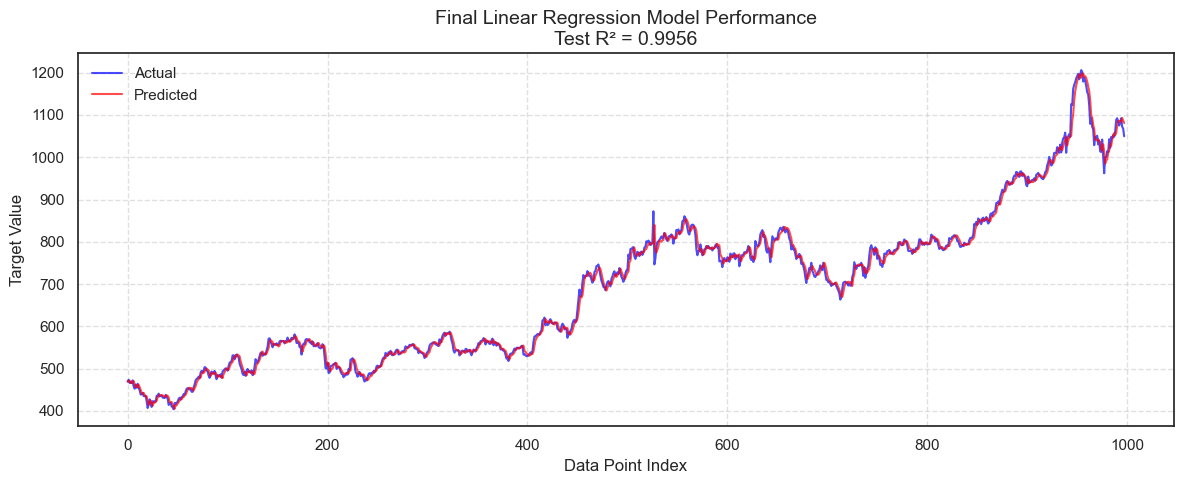

In [39]:
actual_values = y_test.values

# calculate the final R2 score on test data
r2_final = r2_score(actual_values, y_pred_final)

# create the plot
plt.figure(figsize=(12, 5))

plt.plot(actual_values, label="Actual", color="blue", alpha=0.7, linewidth=1.5)
plt.plot(y_pred_final, label="Predicted", color="red", alpha=0.7, linewidth=1.5)

plt.title(f"Final Linear Regression Model Performance\nTest R² = {r2_final:.4f}", fontsize=14)
plt.xlabel("Data Point Index", fontsize=12)
plt.ylabel("Target Value", fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()


**Save the model**

In [40]:
import joblib

# Save the final pipline model
model_filename = "sbin_model.joblib"
joblib.dump(final_model_pipe, model_filename)
print(f"Model successfully saved to '{model_filename}'")

Model successfully saved to 'sbin_model.joblib'
